# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Sid Luthra

**Date:** 9/9/26

In [1]:
# Problem 1: Solved on paper, pdf added to github repo.



In [2]:
#Problem 2:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load the dataset
file_path = '/content/ForeignGifts_edu.csv'
df = pd.read_csv(file_path)
display(df.head())

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


,Foreign Gift Amount
count,2.822100e+04
mean,5.882327e+05
std,3.222011e+06
min,-5.377700e+05
25%,5.700000e+03
50%,9.461500e+04
75%,3.761420e+05
max,1.000000e+08


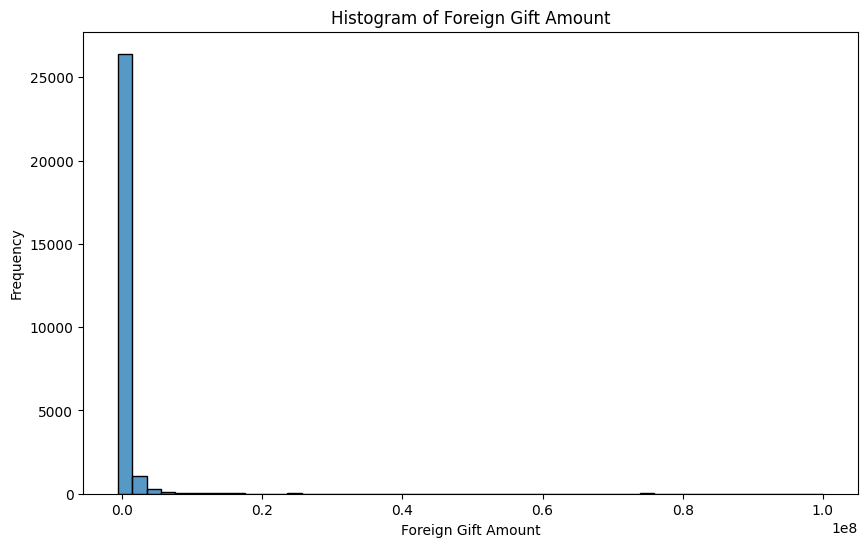

In [3]:
# 2. For Foreign Gift Amount, create a histogram and describe the variable.
display(df['Foreign Gift Amount'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df['Foreign Gift Amount'].dropna(), bins=50, kde=False)
plt.title('Histogram of Foreign Gift Amount')
plt.xlabel('Foreign Gift Amount')
plt.ylabel('Frequency')
plt.show()

**Findings:** The `Foreign Gift Amount` variable is heavily right-skewed. The vast majority of gifts are relatively small compared to a few extremely large outliers, which compresses the histogram and makes it difficult to see the distribution of typical gift amounts without a log transformation.

,Count,Proportion (%)
Gift Type,,
Contract,17274,61.209737
Monetary Gift,10936,38.751285
Real Estate,11,0.038978


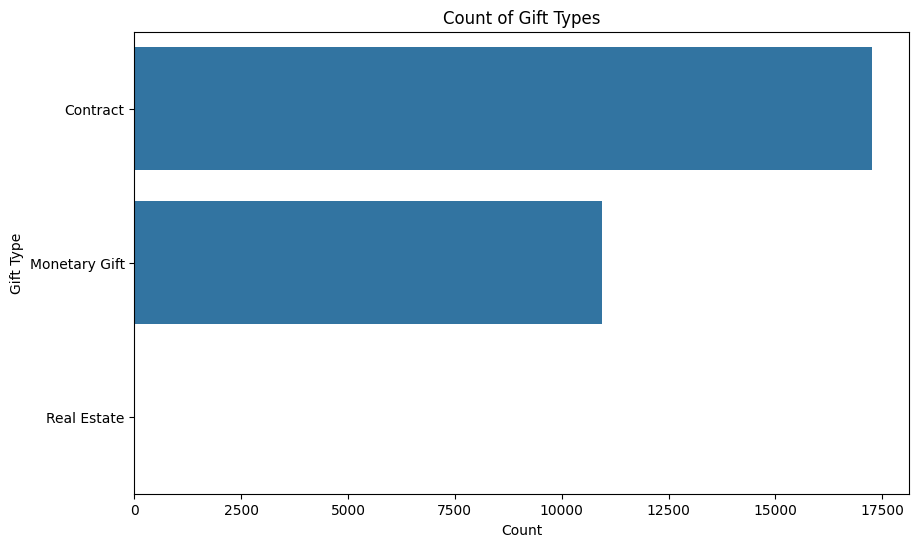

In [4]:
# 3. For Gift Type, create a histogram or value counts table.
# What proportion of the gifts are contracts, real estate, and monetary gifts?

gift_type_counts = df['Gift Type'].value_counts()
gift_type_props = df['Gift Type'].value_counts(normalize=True) * 100

display(pd.DataFrame({'Count': gift_type_counts, 'Proportion (%)': gift_type_props}))

plt.figure(figsize=(10, 6))
sns.countplot(y='Gift Type', data=df, order=df['Gift Type'].value_counts().index)
plt.title('Count of Gift Types')
plt.xlabel('Count')
plt.ylabel('Gift Type')
plt.show()

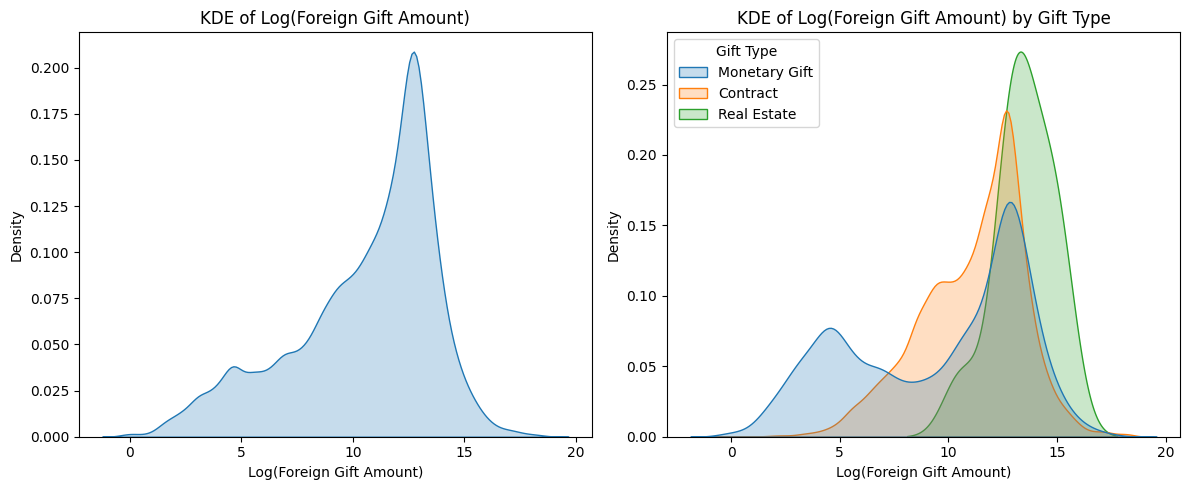

In [5]:
# 4. Create a kernel density plot of the log of Foreign Gift Amount,
# and then a kernel density plot of the log conditional on gift type.

# Calculate log of Foreign Gift Amount (ignoring zeros and negative values if any)
df['Log_Gift_Amount'] = np.log(df[df['Foreign Gift Amount'] > 0]['Foreign Gift Amount'])

plt.figure(figsize=(12, 5))

# Overall KDE
plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x='Log_Gift_Amount', fill=True)
plt.title('KDE of Log(Foreign Gift Amount)')
plt.xlabel('Log(Foreign Gift Amount)')

# Conditional KDE by Gift Type
plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x='Log_Gift_Amount', hue='Gift Type', common_norm=False, fill=True)
plt.title('KDE of Log(Foreign Gift Amount) by Gift Type')
plt.xlabel('Log(Foreign Gift Amount)')

plt.tight_layout()
plt.show()

In [6]:
# 5. What are the top 15 countries in terms of the number of gifts?
# What are the top 15 countries in terms of the amount given?

top_countries_by_number = df['Country of Giftor'].value_counts().head(15)
print("Top 15 Countries by Number of Gifts:")
display(pd.DataFrame(top_countries_by_number))

print("\nTop 15 Countries by Amount Given:")
top_countries_by_amount = df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
display(pd.DataFrame(top_countries_by_amount))

Top 15 Countries by Number of Gifts:


,count
Country of Giftor,
ENGLAND,3655
CHINA,2461
CANADA,2344
JAPAN,1896
SWITZERLAND,1676
SAUDI ARABIA,1610
FRANCE,1437
GERMANY,1394
HONG KONG,1080



Top 15 Countries by Amount Given:


,Foreign Gift Amount
Country of Giftor,
QATAR,2706240869
ENGLAND,1464906771
CHINA,1237952112
SAUDI ARABIA,1065205930
BERMUDA,899593972
CANADA,898160656
HONG KONG,887402529
JAPAN,655954776
SWITZERLAND,619899445


In [7]:
# 6. Which giftors provide the most money, in total?

top_giftors = df.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(10)
print("Top 10 Giftors by Total Amount:")
display(pd.DataFrame(top_giftors))

Top 10 Giftors by Total Amount:


,Foreign Gift Amount
Giftor Name,
Qatar Foundation,1166503744
Qatar Foundation/Qatar National Res,796197000
Qatar Foundation for Education,373945215
Anonymous,338793629
Saudi Arabian Cultural Mission,275221475
HCL,190000000
Church of Jesus Christ of LDS,185203715
Emirates Institute for Advanced Sc,170641244
QIC,148355497


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** b2f4865fdf97a18bdabded5e5f4250da357e89b9
- **AI tool and model used:** ChatGPT: GPT-5.6 Sol

### *Prompts used

1. "Can you help me do phase 2?" (Uploaded PDF of notebook)
2. "Review my Phase 1 solutions for Questions 1 and 2. Identify mathematical or coding errors, missing interpretations, data-quality concerns, and ways to improve the solutions. Give me a concise numbered list of proposed changes, but preserve my original Phase 1 work."

### *AI-proposed changes



1. Correct Question 1, Part 4. The counterexample chooses g(x) = x^3 but then calculates values using x^2. For X = {1, 3} and g(x) = x^3, m(X) = 2, so g(m(X)) = 8, while m(g(X)) = (1^3 + 3^3)/2 = 14. Therefore m(g(X)) ≠ g(m(X)). The function x^3 is also non-decreasing on all real numbers, making it a valid counterexample.

2. Make the Question 1, Part 3 derivation more explicit by showing that cov(X,X) equals the stated sample variance s^2 directly from their identical definitions.

3. In Question 2, explicitly discuss the negative Foreign Gift Amount values. Because log(x) is undefined for non-positive x, state that the KDE analysis only includes Foreign Gift Amount > 0 rather than silently dropping those observations.

4. Add the missing written interpretation of the conditional KDE plot. Monetary gifts appear to have a wider distribution and include substantially smaller positive amounts, while contracts tend to be concentrated at larger log gift amounts. Real estate has very few observations, so its KDE should be interpreted cautiously.

5. Note that the country field contains possible category inconsistencies such as "KOREA" and "SOUTH KOREA." Keep the raw categories for the assignment unless there is evidence that they should be combined, but mention this as a data-quality limitation.

6. Note that Giftor Name appears to contain potentially related names such as "Qatar Foundation," "Qatar Foundation/Qatar National Res," and "Qatar Foundation for Education." Do not automatically merge them without evidence, but acknowledge that name variation can affect giftor totals.

7. Improve the top-country and top-giftor code by using explicit sort_values(ascending=False) and head() operations so that the intended ranking is obvious and reproducible.

8. Add clear textual conclusions after the country and giftor tables rather than relying only on displayed output.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | **Accept** | My Part 4 conclusion was right, but I used squares after defining \(g(x)=x^3\). Recalculating gives \(m(g(X))=14\) and \(g(m(X))=8\). |
| 2 | **Accept** | The definitions show that \(\operatorname{cov}(X,X)\) and \(s^2\) are the same expression. |
| 3 | **Accept** | `describe()` shows negative gift amounts, so I verified that the log calculation only uses values greater than 0. |
| 4 | **Accept with caution** | The KDEs differ, but Real Estate has only 11 observations, so conclusions about that group are limited. |
| 5 | **Accept** | `KOREA` and `SOUTH KOREA` appear separately. I noted this as a possible labeling issue but did not merge them. |
| 6 | **Accept** | Several Qatar Foundation-related names appear separately. I did not combine them without evidence they are the same entity. |
| 7 | **Modify** | My ranking code works, but I can make the sorting and `head()` steps more explicit. |
| 8 | **Accept** | I added short written conclusions so the results are easier to interpret. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

### Phase 2 Revised Solution — Problem 1

For Parts 1–3, I reviewed the derivations and retained them because they correctly follow from the definitions of sample mean and covariance.

For Part 3,

$$
\operatorname{cov}(X,X)
=
\frac{1}{N}\sum_{i=1}^{N}(x_i-m(X))(x_i-m(X))
$$

$$
=
\frac{1}{N}\sum_{i=1}^{N}(x_i-m(X))^2
=
s^2
$$

Thus,

$$
\operatorname{cov}(a+bX,a+bX)
=
b^2\operatorname{cov}(X,X)
=
b^2s^2
$$

### Correction to Part 4

No. Even if \(g\) is non-decreasing, it is not necessarily true that

$$
m(g(X)) = g(m(X))
$$

Consider

$$
X=\{1,3\}
$$

and the non-decreasing function

$$
g(x)=x^3
$$

Then

$$
m(X)=\frac{1+3}{2}=2
$$

so

$$
g(m(X))=2^3=8
$$

However,

$$
m(g(X))
=
\frac{1^3+3^3}{2}
=
\frac{1+27}{2}
=
14
$$

Therefore,

$$
m(g(X))=14 \neq 8=g(m(X))
$$

So a non-decreasing transformation does not, in general, commute with taking the sample mean.

### Phase 2 Revised Solution — Problem 2

I reviewed my Phase 1 analysis and kept the overall approach because it correctly answers the required questions. I made several revisions to improve the interpretation of the results and address data-quality and log-transformation concerns.

In [8]:
# Problem 2 — Phase 2 Revised Solution

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load dataset
file_path = '/content/ForeignGifts_edu.csv'
df = pd.read_csv(file_path)

display(df.head())

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


,Foreign Gift Amount
count,2.822100e+04
mean,5.882327e+05
std,3.222011e+06
min,-5.377700e+05
25%,5.700000e+03
50%,9.461500e+04
75%,3.761420e+05
max,1.000000e+08


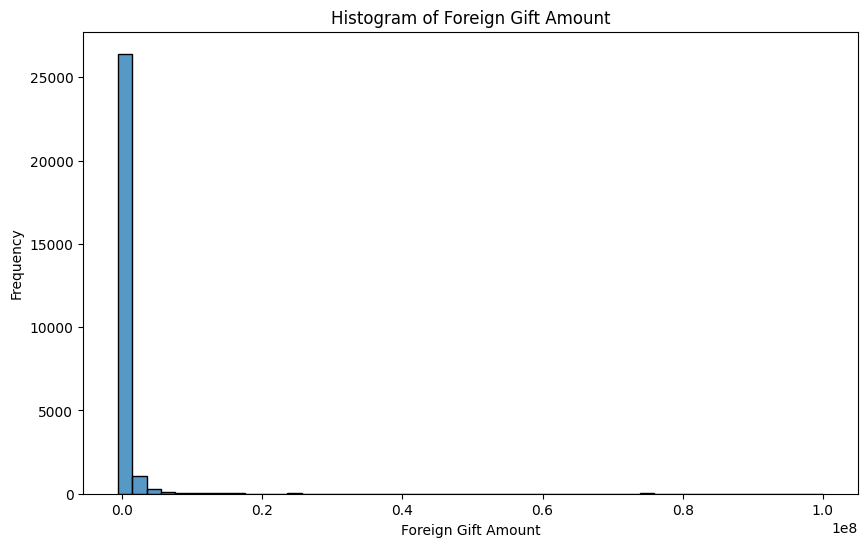

In [9]:
# 2. Foreign Gift Amount

display(df['Foreign Gift Amount'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df['Foreign Gift Amount'].dropna(), bins=50, kde=False)
plt.title('Histogram of Foreign Gift Amount')
plt.xlabel('Foreign Gift Amount')
plt.ylabel('Frequency')
plt.show()

**Interpretation:** The Foreign Gift Amount variable is extremely right-skewed. The median gift is about \$94,615, while the mean is about \$588,233, showing that a relatively small number of very large gifts pull the mean upward. The maximum gift is $100 million.

I also noticed that the minimum Foreign Gift Amount is negative. Because the provided dataset does not explain what negative values represent, I do not make assumptions about their meaning. This is important when taking the logarithm because the log is only defined for positive values.

,Count,Proportion (%)
Gift Type,,
Contract,17274,61.209737
Monetary Gift,10936,38.751285
Real Estate,11,0.038978


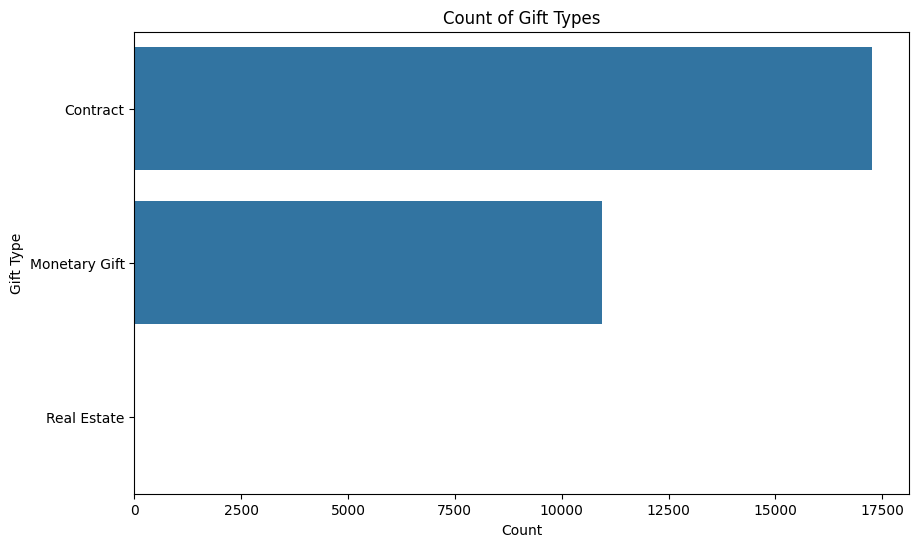

In [10]:
# 3. Gift Type counts and proportions

gift_type_counts = df['Gift Type'].value_counts()
gift_type_props = df['Gift Type'].value_counts(normalize=True) * 100

gift_type_table = pd.DataFrame({
    'Count': gift_type_counts,
    'Proportion (%)': gift_type_props
})

display(gift_type_table)

plt.figure(figsize=(10, 6))
sns.countplot(
    y='Gift Type',
    data=df,
    order=df['Gift Type'].value_counts().index
)
plt.title('Count of Gift Types')
plt.xlabel('Count')
plt.ylabel('Gift Type')
plt.show()

**Interpretation:** Contracts make up about 61.21% of the observations, Monetary Gifts about 38.75%, and Real Estate about 0.04%. Real Estate is extremely rare in this dataset, with only 11 observations.

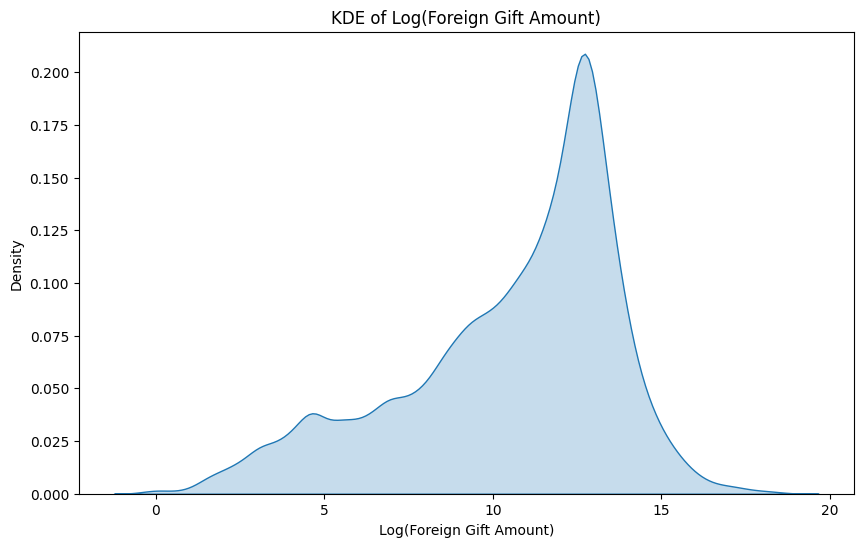

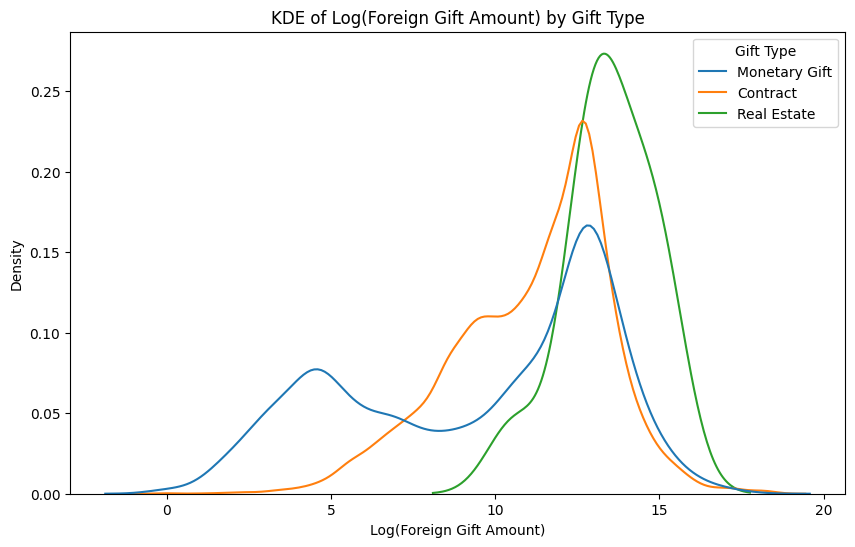

In [11]:
# 4. KDE of log Foreign Gift Amount

# Log is only defined for positive values
positive_gifts = df.loc[df['Foreign Gift Amount'] > 0].copy()

positive_gifts['Log_Gift_Amount'] = np.log(
    positive_gifts['Foreign Gift Amount']
)

# Overall KDE
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=positive_gifts,
    x='Log_Gift_Amount',
    fill=True
)
plt.title('KDE of Log(Foreign Gift Amount)')
plt.xlabel('Log(Foreign Gift Amount)')
plt.show()

# KDE conditional on Gift Type
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=positive_gifts,
    x='Log_Gift_Amount',
    hue='Gift Type',
    common_norm=False
)
plt.title('KDE of Log(Foreign Gift Amount) by Gift Type')
plt.xlabel('Log(Foreign Gift Amount)')
plt.show()

**Patterns noticed:** The log transformation makes the distribution of typical gift amounts much easier to see. Monetary Gifts cover a wider range and include more smaller positive values, while Contracts appear more concentrated at larger log gift amounts.

The Real Estate KDE should be interpreted cautiously because there are only 11 Real Estate observations, so its distribution is based on a very small sample.

In [12]:
# 5. Top 15 countries by number of gifts

top_countries_by_number = (
    df['Country of Giftor']
    .value_counts()
    .head(15)
)

print("Top 15 Countries by Number of Gifts:")
display(top_countries_by_number.to_frame('Number of Gifts'))


# Top 15 countries by total amount given

top_countries_by_amount = (
    df.groupby('Country of Giftor')['Foreign Gift Amount']
      .sum()
      .sort_values(ascending=False)
      .head(15)
)

print("Top 15 Countries by Total Amount Given:")
display(top_countries_by_amount.to_frame('Total Gift Amount'))

Top 15 Countries by Number of Gifts:


,Number of Gifts
Country of Giftor,
ENGLAND,3655
CHINA,2461
CANADA,2344
JAPAN,1896
SWITZERLAND,1676
SAUDI ARABIA,1610
FRANCE,1437
GERMANY,1394
HONG KONG,1080


Top 15 Countries by Total Amount Given:


,Total Gift Amount
Country of Giftor,
QATAR,2706240869
ENGLAND,1464906771
CHINA,1237952112
SAUDI ARABIA,1065205930
BERMUDA,899593972
CANADA,898160656
HONG KONG,887402529
JAPAN,655954776
SWITZERLAND,619899445


**Interpretation:** England has the largest number of gifts, followed by China and Canada. However, Qatar ranks first in total dollar amount given. This shows that the country providing the greatest number of gifts is not necessarily the country providing the greatest total value.

I also noticed that `KOREA` and `SOUTH KOREA` appear as separate categories. I left them unchanged because the dataset does not provide enough information to determine whether they should be combined.

In [13]:
# 6. Giftors providing the most money in total

top_giftors = (
    df.groupby('Giftor Name')['Foreign Gift Amount']
      .sum()
      .sort_values(ascending=False)
      .head(15)
)

print("Top Giftors by Total Amount:")
display(top_giftors.to_frame('Total Gift Amount'))

Top Giftors by Total Amount:


,Total Gift Amount
Giftor Name,
Qatar Foundation,1166503744
Qatar Foundation/Qatar National Res,796197000
Qatar Foundation for Education,373945215
Anonymous,338793629
Saudi Arabian Cultural Mission,275221475
HCL,190000000
Church of Jesus Christ of LDS,185203715
Emirates Institute for Advanced Sc,170641244
QIC,148355497


**Interpretation:** Qatar Foundation is the largest individual Giftor Name category in the dataset by total amount.

However, several Qatar Foundation-related names appear separately in the dataset. I did not combine these names because there is not enough information to confirm that they represent the same entity. Similar naming differences could affect the totals for individual giftors.

### *Reflection on AI assistance
In your own words without generative AI.

The most major change I made during phase 2 was correcting parts of my original work instead of actually changing anything. In Problem 1, I caught an error in Part 4 where I defined \(g(x)=x^3\) but then used squared values in the calculation. After correcting that issue, the outcome was the same. For problem 2, I improved the explanations of the gift amount distributions, plots, and the country and giftor rankings.

A limitation of AI suggestions was that they still needed to be checked against the actual data set. I checked the changes made by AI by checking my original formulas, reviewing output, comparing the gift type counts, and looking back at the plots and results. I also made sure that the suggestions matched what the data actually showed instead of accepting them automatically. There were still some small concerns with the data, such as unusual negative gift amounts and categories that may have inconsistent names.